In [1]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from plotly import graph_objs as go

from src.green_gecko_model import CAModel, make_seed

# Visualizing attractors
### Load model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

# Whether to scale the attractor or not
scale_attractor = True

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1_nr3/8000.weights.h5")
None

2026-04-12 21:46:34.994410: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-12 21:46:34.994440: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-12 21:46:34.994446: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-12 21:46:34.994464: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 21:46:34.994477: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-12 21:46:35.377365: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run model

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(3000): # It's supposed to be 3000
    x = model(x)
    states.append(tf.identity(x).numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025739107..1.0329971].


(3001, 1, 40, 40, 16)
(40, 40, 16)


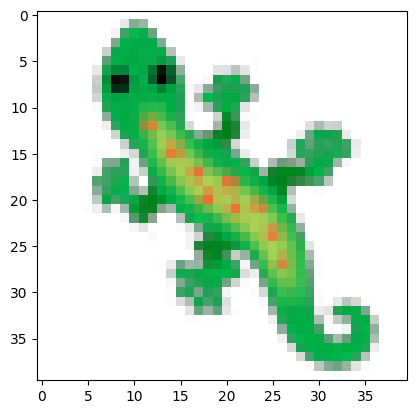

In [5]:
states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] #[:,:,10:-10,10:-10]
print(states_np.shape)

x_star = states_np[-1,0]
print(x_star.shape)
plt.imshow(x_star[:,:,:4])

### Flatten states and scale

In [6]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)
timesteps = np.arange(flattened_attractor_states.shape[0])

if scale_attractor:
    scaler = StandardScaler()
    scaler = scaler.fit(flattened_attractor_states[2000:]) # originally 2000
    flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

### PCA

In [7]:
t1 = 400
t2 = 1000 # usually 1000
t3 = 3000 # usually 3000

total_pca = PCA(n_components=2).fit_transform(flattened_attractor_states[:t1] if not scale_attractor else flattened_attractor_states_scaled[:t1])

# from 500 timestep 
pca_from_500 = PCA(n_components=3).fit_transform(flattened_attractor_states[t1:t2] if not scale_attractor else flattened_attractor_states_scaled[t1:t2])
timesteps_from_500 = np.arange(pca_from_500.shape[0]) #timesteps[400:]

# from 2000 timestep 
attractor_pca = PCA(n_components=13)
pca_from_2000 = attractor_pca.fit_transform(flattened_attractor_states[t2:t3] if not scale_attractor else flattened_attractor_states_scaled[t2:t3]) # For the non-stochastic, it was 1000
#pca_from_2000 = Isomap(n_components=3).fit_transform(flattened_attractor_states[2000:])
timesteps_from_2000 = np.arange(pca_from_2000.shape[0]) #timesteps[400:]

### Display

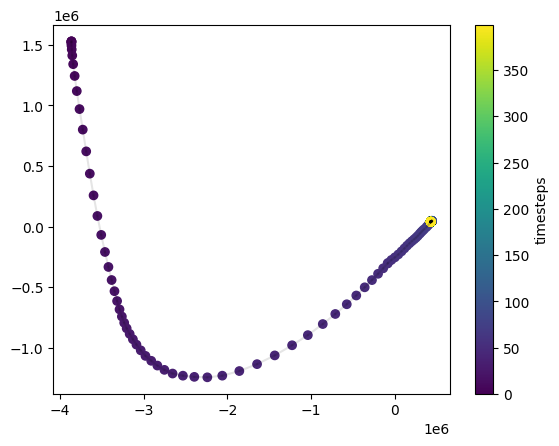

In [8]:

plt.figure()
plt.scatter(total_pca[:,0], total_pca[:,1], c=timesteps[:t1])

for i in range(len(total_pca) - 1):
    plt.plot([total_pca[i,0], total_pca[i+1,0]], [total_pca[i,1], total_pca[i+1,1]], 'k-', alpha=0.1)

plt.colorbar(label="timesteps")
plt.show()

fig = go.Figure(data=go.Scatter3d(
    x=pca_from_500[:,0],
    y=pca_from_500[:,1],
    z=pca_from_500[:,2],
    mode='lines',
    line=dict(
        colorscale="plasma",
        color=timesteps_from_500
    )
))
fig.update_traces(selector=dict(mode='lines'))

fig.add_scatter3d(
    x=pca_from_500[:,0],
    y=pca_from_500[:,1],
    z=pca_from_500[:,2],
    mode='markers',
    marker=dict(
        size=2,
        opacity=1.0,
        colorscale="plasma",
        color=timesteps_from_500
    )
)
fig.update_traces(selector=dict(mode='markers'))

fig.show()

fig = go.Figure(data=go.Scatter3d(
    x=pca_from_2000[:,0],
    y=pca_from_2000[:,1],
    z=pca_from_2000[:,2],
    mode='lines',
    line=dict(
        #size=2,
        #opacity=1.0,
        colorscale="plasma",
        color=timesteps_from_2000
    )

))
fig.update_traces(selector=dict(mode='lines'))

fig.add_scatter3d(
    x=pca_from_2000[:,0],
    y=pca_from_2000[:,1],
    z=pca_from_2000[:,2],
    mode='markers',
    marker=dict(
        size=2,
        opacity=1.0,
        colorscale="plasma",
        color=timesteps_from_2000
    )
)
fig.update_traces(selector=dict(mode='markers'))


fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

"""fig.update_layout(
    width=640,
    height=640
)"""

fig.show()


### Create axes for figure purposes

In [9]:

# Define start and end points
x_start, y_start, z_start = 0, 0, 0
x_end, y_end, z_end = 0, 0, 0

fig = go.Figure(data=[
    # The shaft
    go.Scatter3d(x=[x_start, 0.7], y=[y_start, y_end], z=[z_start, z_end],
                 mode='lines', line=dict(color='magenta', width=20)),
    # The arrowhead
    go.Cone(x=[1], y=[y_end], z=[z_end],
            u=[0.7 - x_start], v=[y_end - y_start], w=[z_end - z_start],
            sizemode="absolute", sizeref=0.4, anchor="tip", showscale=False,
            colorscale=[[0, 'magenta'], [1, 'magenta']], opacity=1.0),

    # The shaft
    go.Scatter3d(x=[x_start, x_end], y=[y_start, 0.7], z=[z_start, z_end],
                 mode='lines', line=dict(color='blue', width=20)),
    # The arrowhead
    go.Cone(x=[x_end], y=[1], z=[z_end],
            u=[x_end - x_start], v=[0.7 - y_start], w=[z_end - z_start],
            sizemode="absolute", sizeref=0.4, anchor="tip", showscale=False,
            colorscale=[[0, 'blue'], [1, 'blue']], opacity=1.0),

    # The shaft
    go.Scatter3d(x=[x_start, x_end], y=[y_start, y_end], z=[z_start, 0.7],
                 mode='lines', line=dict(color='green', width=20)),
    # The arrowhead
    go.Cone(x=[x_end], y=[y_end], z=[1],
            u=[x_end - x_start], v=[y_end - y_start], w=[0.7 - z_start],
            sizemode="absolute", sizeref=0.4, anchor="tip", showscale=False,
            colorscale=[[0, 'green'], [1, 'green']], opacity=1.0),
    
])

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

fig.show()

### Colorbar for figure purposes

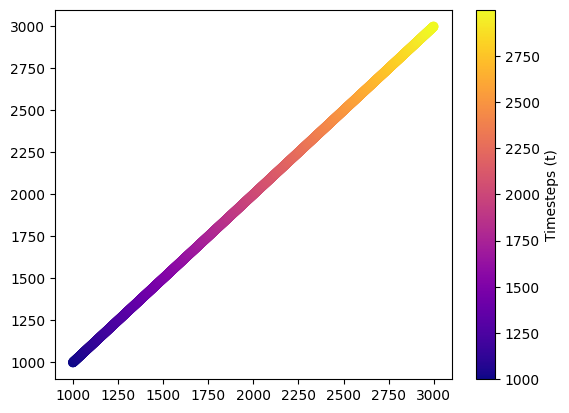

In [10]:
plt.scatter(np.arange(t2,t3), np.arange(t2,t3), cmap="plasma", c=np.arange(t2,t3))
plt.colorbar(label="Timesteps (t)")
plt.savefig("colorbar.svg")